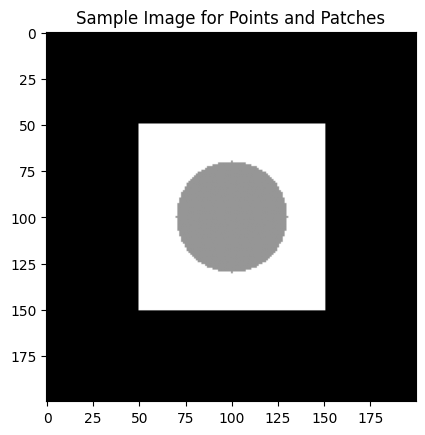

In [2]:
# Import required libraries
import numpy as np                 # For numerical operations
import cv2                         # For image processing
import matplotlib.pyplot as plt    # For displaying images

# Create a blank grayscale image (200x200 pixels)
image = np.zeros((200, 200), dtype=np.uint8)

# Draw a white rectangle
cv2.rectangle(image, (50, 50), (150, 150), 255, -1)

# Draw a white circle inside rectangle
cv2.circle(image, (100, 100), 30, 150, -1)

# Display the image
plt.imshow(image, cmap='gray')
plt.title("Sample Image for Points and Patches")
plt.axis("on")
plt.show()

Image loaded successfully!


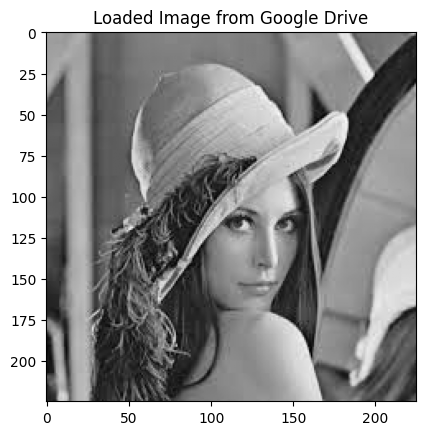

In [34]:
# Import required libraries
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Path of image inside Google Drive
image_path = "/content/drive/MyDrive/M.Tech_CVT/Points and Patches.jpg"   # Change folder name accordingly

# Read image
image = cv2.imread(image_path)

# Check if image loaded properly
if image is None:
    print("Error: Image not found. Check path.")
else:
    print("Image loaded successfully!")

# Convert to grayscale (since your previous code was grayscale)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Display image
plt.imshow(gray, cmap='gray')
plt.title("Loaded Image from Google Drive")
plt.axis("on")
plt.show()

Selected Point Coordinates: (100, 100)
Pixel Intensity at that Point: [158 106 170]


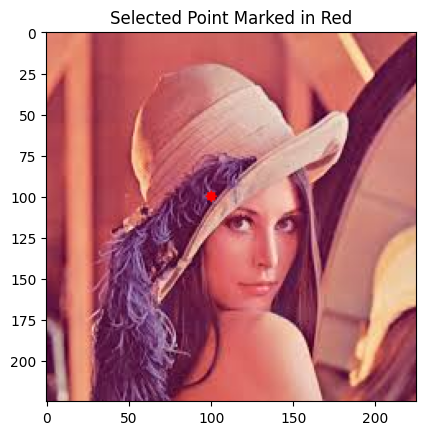

In [36]:
# Select a point manually
x = 100   # Row index
y = 100   # Column index

# Get pixel intensity at that point
pixel_value = image[x, y]

print("Selected Point Coordinates:", (x, y))
print("Pixel Intensity at that Point:", pixel_value)

# Mark the point on the image
image_copy = image.copy() # The image is already BGR, so just make a copy
cv2.circle(image_copy, (y, x), 3, (0,0,255), -1)

plt.imshow(cv2.cvtColor(image_copy, cv2.COLOR_BGR2RGB)) # Convert BGR to RGB for matplotlib display
plt.title("Selected Point Marked in Red")
plt.axis("on")
plt.show()

Patch Shape: (5, 5, 3)


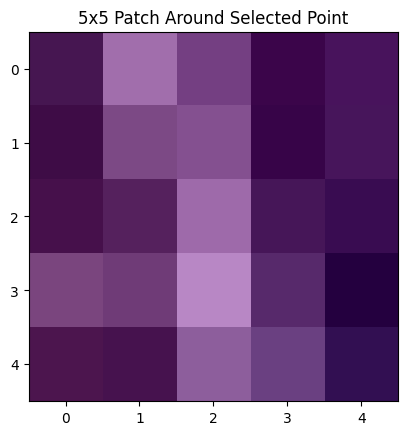

In [37]:
# Define patch size
patch_size = 5

# Calculate half size
half = patch_size // 2

# Extract patch using slicing
patch = image[x-half:x+half+1, y-half:y+half+1]

print("Patch Shape:", patch.shape)

# Display patch
plt.imshow(patch, cmap='gray')
plt.title("5x5 Patch Around Selected Point")
plt.axis("on")
plt.show()

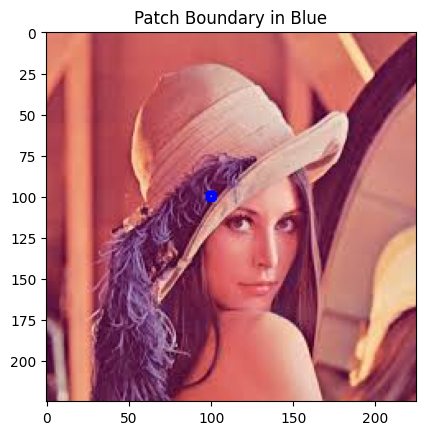

In [39]:
# Draw rectangle showing patch boundary
top_left = (y-half, x-half)
bottom_right = (y+half, x+half)

image_patch_visual = image.copy() # image is already BGR, so make a copy directly

cv2.rectangle(image_patch_visual, top_left, bottom_right, (255,0,0), 2)

plt.imshow(cv2.cvtColor(image_patch_visual, cv2.COLOR_BGR2RGB)) # Convert BGR to RGB for matplotlib display
plt.title("Patch Boundary in Blue")
plt.axis("on")
plt.show()

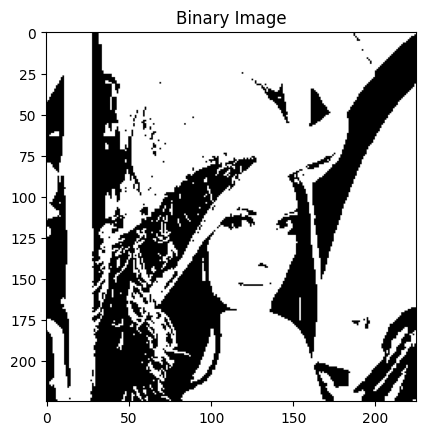

In [42]:
# Convert grayscale image to binary
_, binary = cv2.threshold(gray, 100, 255, cv2.THRESH_BINARY)

plt.imshow(binary, cmap='gray')
plt.title("Binary Image")
plt.axis("on")
plt.show()

Total Objects (excluding background): 73


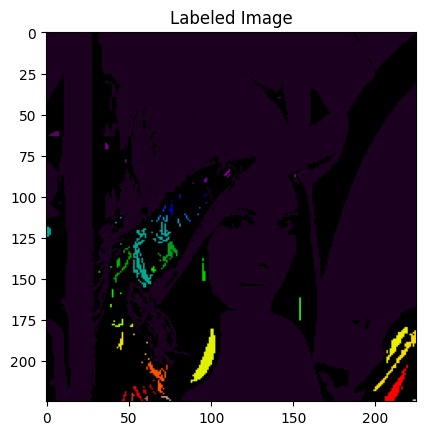

In [43]:
# Connected Component Labeling
num_labels, labels = cv2.connectedComponents(binary)

print("Total Objects (excluding background):", num_labels-1)

plt.imshow(labels, cmap='nipy_spectral')
plt.title("Labeled Image")
plt.axis("on")
plt.show()

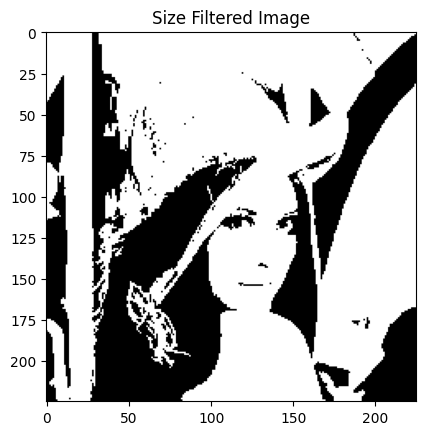

In [44]:
filtered = np.zeros_like(binary)

for i in range(1, num_labels):
    mask = labels == i
    if np.sum(mask) > 500:
        filtered[mask] = 255

plt.imshow(filtered, cmap='gray')
plt.title("Size Filtered Image")
plt.axis("on")
plt.show()

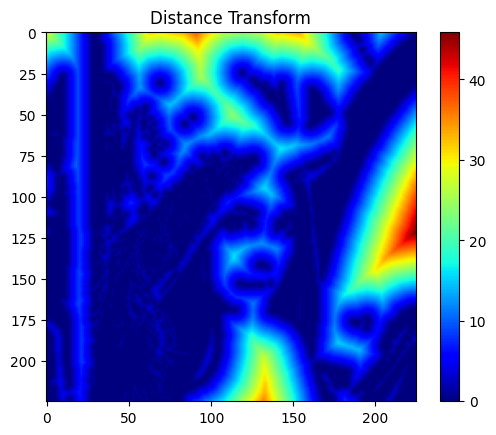

In [45]:
distance = cv2.distanceTransform(binary, cv2.DIST_L2, 5)

plt.imshow(distance, cmap='jet')
plt.title("Distance Transform")
plt.colorbar()
plt.show()

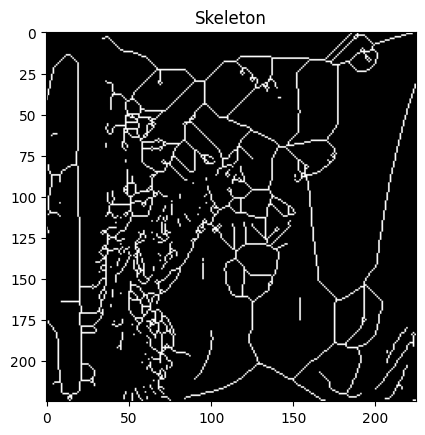

In [46]:
from skimage.morphology import skeletonize

binary_bool = binary > 0
skeleton = skeletonize(binary_bool)

plt.imshow(skeleton, cmap='gray')
plt.title("Skeleton")
plt.axis("on")
plt.show()

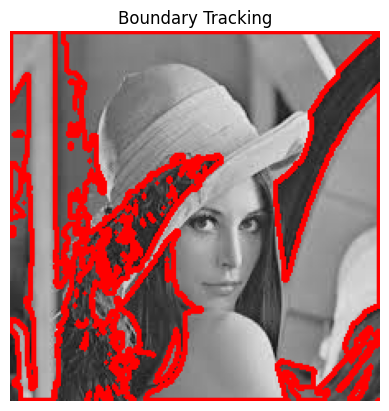

In [48]:
contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

contour_img = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
cv2.drawContours(contour_img, contours, -1, (0,0,255), 2)

plt.imshow(cv2.cvtColor(contour_img, cv2.COLOR_BGR2RGB))
plt.title("Boundary Tracking")
plt.axis("off")
plt.show()

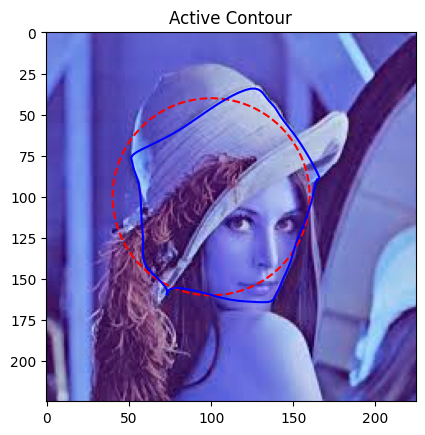

In [49]:
from skimage.segmentation import active_contour
from skimage.filters import gaussian

smoothed = gaussian(image, 3)

s = np.linspace(0, 2*np.pi, 200)
r = 100 + 60*np.sin(s)
c = 100 + 60*np.cos(s)
init = np.array([r, c]).T

snake = active_contour(smoothed, init)

plt.imshow(image, cmap='gray')
plt.plot(init[:,1], init[:,0], '--r')
plt.plot(snake[:,1], snake[:,0], '-b')
plt.title("Active Contour")
plt.show()

In [50]:
moments = cv2.moments(binary)
hu = cv2.HuMoments(moments)

print("Hu Moments:\n", hu)

Hu Moments:
 [[ 9.38558654e-04]
 [ 1.12783282e-08]
 [ 1.29105277e-12]
 [ 7.71780263e-12]
 [-2.08792204e-23]
 [-7.32357372e-16]
 [-1.25524499e-23]]


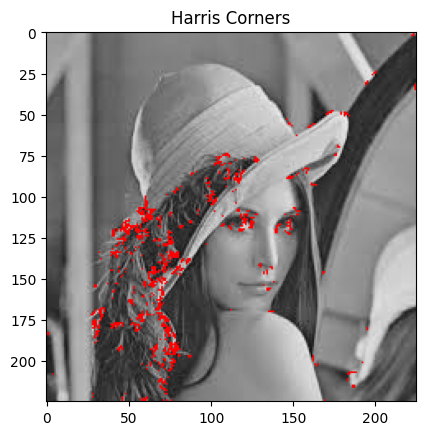

In [52]:
corners = cv2.cornerHarris(np.float32(gray), 2, 3, 0.04)

corner_img = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
corner_img[corners > 0.01 * corners.max()] = [0,0,255]

plt.imshow(cv2.cvtColor(corner_img, cv2.COLOR_BGR2RGB))
plt.title("Harris Corners")
plt.axis("on")
plt.show()

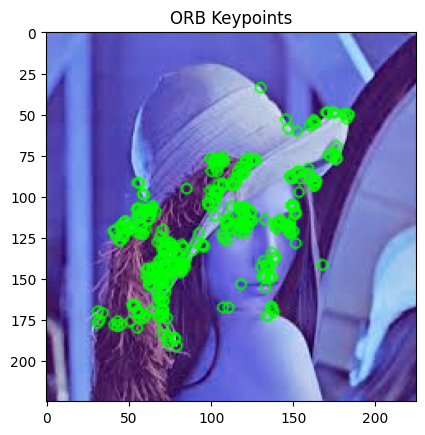

In [53]:
orb = cv2.ORB_create()
kp, des = orb.detectAndCompute(image, None)

orb_img = cv2.drawKeypoints(image, kp, None, color=(0,255,0))

plt.imshow(orb_img, cmap='gray')
plt.title("ORB Keypoints")
plt.axis("on")
plt.show()

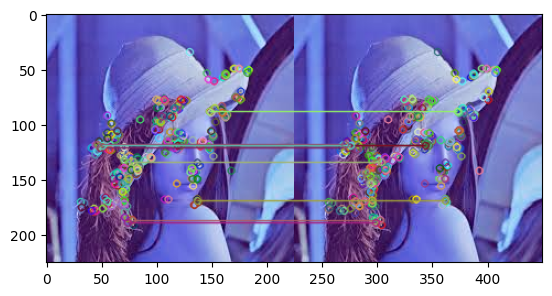

In [54]:
# Use same image for demo
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

matches = bf.match(des, des)
matches = sorted(matches, key=lambda x: x.distance)

match_img = cv2.drawMatches(image, kp, image, kp, matches[:10], None)

plt.imshow(match_img)
plt.axis("on")
plt.show()

In [56]:
p0 = cv2.goodFeaturesToTrack(gray, 50, 0.3, 7)
p1, st, err = cv2.calcOpticalFlowPyrLK(gray, gray, p0, None)

print("Tracked Points:", len(p1))

Tracked Points: 18


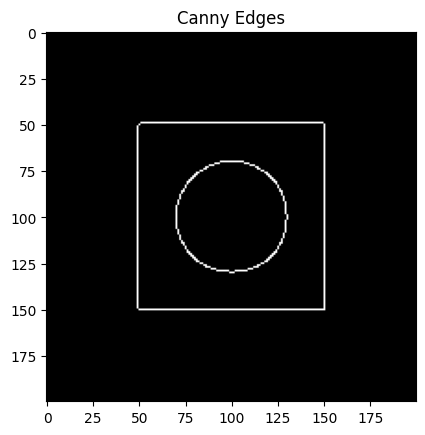

In [26]:
edges = cv2.Canny(image, 100, 200)

plt.imshow(edges, cmap='gray')
plt.title("Canny Edges")
plt.axis("on")
plt.show()

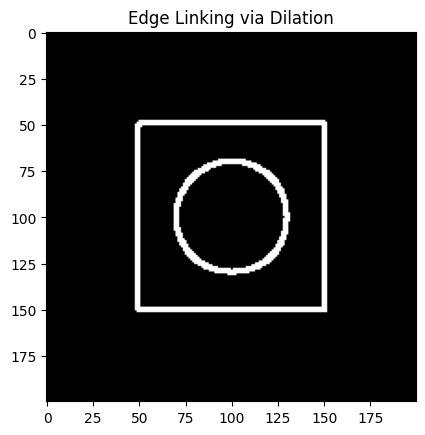

In [57]:
kernel = np.ones((3,3), np.uint8)
linked = cv2.dilate(edges, kernel, iterations=1)

plt.imshow(linked, cmap='gray')
plt.title("Edge Linking via Dilation")
plt.axis("on")
plt.show()

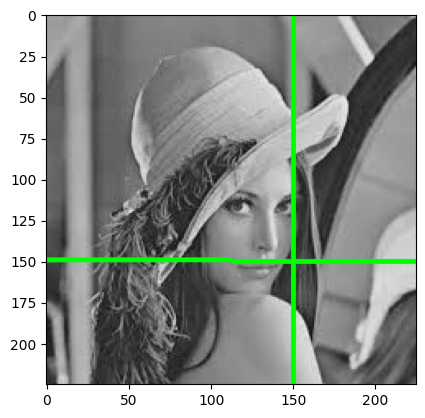

In [59]:
lines = cv2.HoughLines(edges, 1, np.pi/180, 100)

line_img = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

for line in lines[:3]:
    rho, theta = line[0]
    a = np.cos(theta)
    b = np.sin(theta)
    x0 = a*rho
    y0 = b*rho
    x1 = int(x0 + 1000*(-b))
    y1 = int(y0 + 1000*(a))
    x2 = int(x0 - 1000*(-b))
    y2 = int(y0 - 1000*(a))
    cv2.line(line_img, (x1,y1), (x2,y2), (0,255,0), 2)

plt.imshow(cv2.cvtColor(line_img, cv2.COLOR_BGR2RGB))
plt.axis("on")
plt.show()

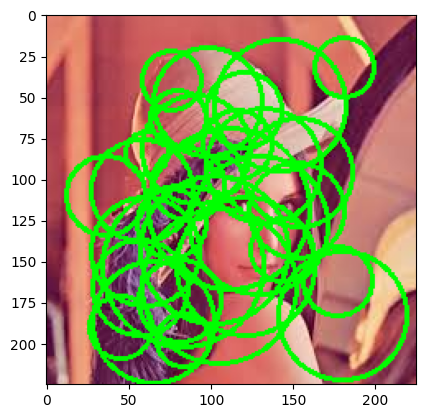

In [62]:
circles = cv2.HoughCircles(gray, cv2.HOUGH_GRADIENT, 1, 20,
                           param1=50, param2=30,
                           minRadius=10, maxRadius=50)

circle_img = image.copy() # Make a copy of the original color image

if circles is not None:
    for circle in circles[0]:
        cv2.circle(circle_img, (int(circle[0]), int(circle[1])),
                   int(circle[2]), (0,255,0), 2)

plt.imshow(cv2.cvtColor(circle_img, cv2.COLOR_BGR2RGB)) # Convert BGR to RGB for matplotlib display
plt.axis("on")
plt.show()

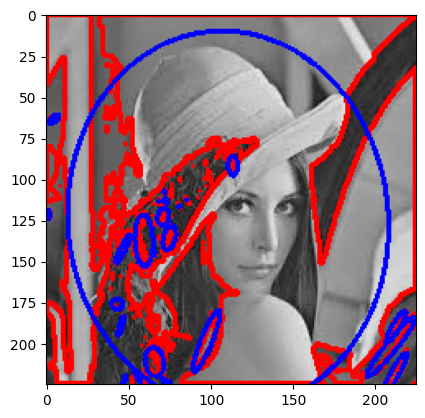

In [64]:
for cnt in contours:
    if len(cnt) >= 5:
        try:
            ellipse = cv2.fitEllipse(cnt)
            # Check for valid width and height before drawing
            if not np.isnan(ellipse[1][0]) and not np.isnan(ellipse[1][1]) and ellipse[1][0] > 0 and ellipse[1][1] > 0:
                cv2.ellipse(contour_img, ellipse, (255,0,0), 2)
        except cv2.error: # Catch potential errors from cv2.fitEllipse itself for some contours
            pass # Skip this contour if ellipse fitting fails

plt.imshow(cv2.cvtColor(contour_img, cv2.COLOR_BGR2RGB))
plt.axis("on")
plt.show()